# Parameter-Efficient Federated Continual Learning (PE-FCL)
===========================================================
This notebook demonstrates Parameter-Efficient Federated Continual Learning (PE-FCL) on the MIT-BIH Arrhythmia Database. We evaluate multiple experiments combining **Federated Averaging (FedAvg)**, **Elastic Weight Consolidation (EWC)**, and **Low-Rank Adaptation (LoRA)** across sequential tasks.

In [1]:
import os
import random
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from mit_bih import (
    create_federated_continual_clients,
    ECGCNN,
    save_plot
)
from mit_bih.cl import (
    FocalLoss,
    compute_fisher,
    train_local_continual,
    evaluate_model as base_evaluate_model
)
from mit_bih.fl import federated_average_dict


## 1. Configurations & Data Loading
We load our segmented dataset and patient mappings. For this notebook demonstration, we will run the experiments on **1 seed** (seed 42) for **10 rounds** total (5 rounds per task) to illustrate the training loop quickly. We downsample the training dataset to 5% of its size so it executes in under a minute on CPU.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

DATA_DIR = os.path.abspath("../../data/raw/mitdb")
MODELS_DIR = os.path.abspath("assets/models")
os.makedirs(MODELS_DIR, exist_ok=True)

NUM_CLIENTS = 3
NUM_ROUNDS = 10
LOCAL_EPOCHS = 3
BACKBONE_PRETRAIN_ROUNDS = 3
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PATIENCE = 3
DROPOUT_RATE = 0.3
LORA_RANK = 8
LORA_ALPHA = 1.0
EWC_LAMBDA_FULL = 50.0
EWC_LAMBDA_LORA = 1.0
SEED = 42

TASK_CLASSES = [
    [0, 1, 2],   # Task 1: Normal, SVEB, VEB
    [3, 4]       # Task 2: Fusion, Unknown
]
NUM_TASKS = len(TASK_CLASSES)
ROUNDS_PER_TASK = NUM_ROUNDS // NUM_TASKS

CLASS_NAMES = ["Normal", "SVEB", "V", "Fusion", "Unknown"]

TRAIN_PATIENTS = [
    '101', '106', '108', '109', '112', '114',
    '115', '116', '118', '119', '122', '124',
    '201', '203', '205', '207', '208', '209',
    '215', '220', '223', '230'
]
TEST_PATIENTS = [
    '100', '103', '104', '105', '111', '113',
    '117', '121', '123', '200', '210', '212',
    '213', '214', '217', '219', '221', '222',
    '228', '231', '232', '233', '234'
]

def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(SEED)

client_loaders, test_loader_full, test_loaders_by_task, class_weights = create_federated_continual_clients(
    TRAIN_PATIENTS, TEST_PATIENTS, DATA_DIR,
    num_clients=NUM_CLIENTS, task_classes=TASK_CLASSES,
    split_seed=SEED, batch_size=BATCH_SIZE,
    downsample_fraction=0.05
)


Running on: cpu

  Loading data for Federated Continual Learning...
  Found preprocessed arrays in /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/data. Loading in-memory...
  Downsampled test set by 5.0% -> 2600 samples
  Test set: 2,600 beats (Task split: T1=2384, T2=216)

  Client 1 patients: ['101', '106', '108', '109', '112', '114', '115']
  Client 1: 582 train | 146 val | task sizes = [580, 2]

  Client 2 patients: ['116', '118', '119', '122', '124', '201', '203']
  Client 2: 628 train | 158 val | task sizes = [628, 0]

  Client 3 patients: ['205', '207', '208', '209', '215', '220', '223', '230']
  Client 3: 830 train | 208 val | task sizes = [813, 17]


## 2. Evaluation & Pretraining Helpers

In [3]:
def evaluate_model(model, dataloader):
    if dataloader is None or len(dataloader) == 0:
        return None
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    if len(y_true) == 0:
        return None
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall"   : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1"       : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "cm"       : confusion_matrix(y_true, y_pred, labels=list(range(5))),
        "preds"    : y_pred,
        "true"     : y_true
    }

def pretrain_backbone(use_fedavg, client_loaders, criterion):
    print(f"Pretraining backbone on Task 1 data...")
    pretrain_model = ECGCNN(use_lora=False, dropout_rate=DROPOUT_RATE).to(DEVICE)
    client_models = [copy.deepcopy(pretrain_model) for _ in range(NUM_CLIENTS)]
    client_sizes_task1 = [cl['task_sizes'][0] for cl in client_loaders]
    for rnd in range(BACKBONE_PRETRAIN_ROUNDS):
        local_weights = []
        for cid in range(NUM_CLIENTS):
            train_loader = client_loaders[cid]['train_by_task'][0]
            val_loader   = client_loaders[cid]['val_by_task'][0]
            client_models[cid] = train_local_continual(
                client_models[cid], train_loader, val_loader, criterion,
                local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, patience=PATIENCE,
                use_ewc=False, device=DEVICE
)
            local_weights.append(copy.deepcopy(client_models[cid].state_dict()))
        if use_fedavg:
            agg = federated_average_dict(local_weights, client_sizes_task1)
            pretrain_model.load_state_dict(agg)
            for cid in range(NUM_CLIENTS):
                client_models[cid].load_state_dict(copy.deepcopy(agg))
        else:
            pretrain_model = copy.deepcopy(client_models[0])
    print(f"Backbone pretraining done.")
    return pretrain_model

## 3. Experiment Runner

In [4]:
def run_experiment(name, use_fedavg, use_ewc, use_lora):
    print(f"\nRunning Experiment: {name}")
    criterion = FocalLoss(gamma=2.0)
    global_model = ECGCNN(use_lora=use_lora, dropout_rate=DROPOUT_RATE, lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA).to(DEVICE)
    if use_lora:
        pretrained = pretrain_backbone(use_fedavg, client_loaders, criterion)
        global_model.load_pretrained_backbone(pretrained)
    client_fisher = [None] * NUM_CLIENTS
    client_optpar = [None] * NUM_CLIENTS
    round_val_accs = []
    per_task_acc_when_learned = [None] * NUM_TASKS
    client_models = [copy.deepcopy(global_model) for _ in range(NUM_CLIENTS)]
    for rnd in range(NUM_ROUNDS):
        task = rnd // ROUNDS_PER_TASK
        is_last_round_of_task = (rnd + 1) % ROUNDS_PER_TASK == 0
        client_sizes_this_task = [cl['task_sizes'][task] for cl in client_loaders]
        local_weights = []
        round_val_sum = 0.0
        round_val_n = 0
        for cid in range(NUM_CLIENTS):
            train_loader = client_loaders[cid]['train_by_task'][task]
            val_loader   = client_loaders[cid]['val_by_task'][task]
            client_models[cid] = train_local_continual(
                client_models[cid], train_loader, val_loader, criterion,
                local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, patience=PATIENCE,
                use_ewc=use_ewc, fisher=client_fisher[cid], opt_par=client_optpar[cid],
                ewc_lambda_full=EWC_LAMBDA_FULL, ewc_lambda_lora=EWC_LAMBDA_LORA,
                device=DEVICE
            )
            if use_lora:
                lp = client_models[cid].get_lora_params()
                local_weights.append({'A': lp['A'], 'B': lp['B']})
            else:
                local_weights.append(copy.deepcopy(client_models[cid].state_dict()))
            if val_loader is not None and len(val_loader) > 0:
                client_models[cid].eval()
                correct, total = 0, 0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                        outputs = client_models[cid](inputs)
                        preds = outputs.argmax(dim=1)
                        correct += (preds == labels).sum().item()
                        total += labels.size(0)
                round_val_sum += (100 * correct / total) if total > 0 else 0.0
                round_val_n += 1
        if use_fedavg:
            agg = federated_average_dict(local_weights, client_sizes_this_task)
            if use_lora:
                for cid in range(NUM_CLIENTS):
                    client_models[cid].set_lora_params({'A': agg['A'], 'B': agg['B']})
                global_model.set_lora_params({'A': agg['A'], 'B': agg['B']})
            else:
                global_model.load_state_dict(agg)
                for cid in range(NUM_CLIENTS):
                    client_models[cid].load_state_dict(copy.deepcopy(agg))
        else:
            global_model = copy.deepcopy(client_models[0])
        avg_val = (round_val_sum / round_val_n) if round_val_n else 0.0
        round_val_accs.append(avg_val)
        if is_last_round_of_task:
            if use_ewc:
                for cid in range(NUM_CLIENTS):
                    fisher, opt_par = compute_fisher(
                        client_models[cid], client_loaders[cid]['train_by_task'][task],
                        criterion, device=DEVICE
                    )
                    if client_fisher[cid] is None:
                        client_fisher[cid] = fisher
                        client_optpar[cid] = opt_par
                    else: 
                        for k in fisher:
                            client_fisher[cid][k] = client_fisher[cid].get(k, torch.zeros_like(fisher[k])) + fisher[k]
                        client_optpar[cid] = opt_par
            task_test_loader = test_loaders_by_task[task]
            m = evaluate_model(global_model, task_test_loader)
            per_task_acc_when_learned[task] = (m["accuracy"] * 100 if m is not None else None)
            
    metrics = evaluate_model(global_model, test_loader_full)
    
    # Save the aggregated global model weights under the local assets folder
    clean_name = name.lower().replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "").replace("-", "_")
    model_save_path = os.path.join(MODELS_DIR, f"{clean_name}_model.pth")
    torch.save(global_model.state_dict(), model_save_path)
    print(f"Saved {name} model weights to: {model_save_path}")
    
    return metrics, round_val_accs


## 4. Execution of Experiments

In [5]:
experiments = [
    {"name": "FedAvg", "fedavg": True,  "ewc": False, "lora": False},
    {"name": "FedAvg + EWC", "fedavg": True,  "ewc": True,  "lora": False},
    {"name": "FedAvg + LoRA", "fedavg": True,  "ewc": False, "lora": True},
    {"name": "FedAvg + EWC + LoRA (PE-FCL)", "fedavg": True,  "ewc": True,  "lora": True},
]

results = {}
for exp in experiments:
    metrics, val_accs = run_experiment(exp['name'], exp['fedavg'], exp['ewc'], exp['lora'])
    results[exp['name']] = {
        'acc': metrics['accuracy'] * 100,
        'f1': metrics['f1'] * 100,
        'val_accs': val_accs
    }

print("\n--- SUMMARY OF RESULTS ---")
for name, res in results.items():
    print(f"{name:<30} | Test Accuracy: {res['acc']:.2f}% | Test F1: {res['f1']:.2f}%")


Running Experiment: FedAvg


      Epoch 1/3 | Train Loss: 0.4810 (task=0.4810 ewc=0.0000) | Val Loss: 0.5190 | Val Acc: 45.89%


      Epoch 2/3 | Train Loss: 0.0939 (task=0.0939 ewc=0.0000) | Val Loss: 0.0500 | Val Acc: 97.26%


      Epoch 3/3 | Train Loss: 0.0447 (task=0.0447 ewc=0.0000) | Val Loss: 0.0399 | Val Acc: 97.26%


      Epoch 1/3 | Train Loss: 0.5752 (task=0.5752 ewc=0.0000) | Val Loss: 0.4968 | Val Acc: 73.42%


...

      Epoch 1/3 | Train Loss: 9.2412 (task=9.2412 ewc=0.0000) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 9.9220 (task=9.9220 ewc=0.0000) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 7.9366 (task=7.9366 ewc=0.0000) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 8.6508 (task=8.6508 ewc=0.0000) | Val Loss: 8.4379 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 8.8088 (task=8.8088 ewc=0.0000) | Val Loss: 8.3673 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 8.0531 (task=8.0531 ewc=0.0000) | Val Loss: 8.2978 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 8.9190 (task=8.9190 ewc=0.0000) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 8.5300 (task=8.5299 ewc=0.0001) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 7.6582 (task=7.6581 ewc=0.0001) | Val Loss: 0.0000 | Val Acc: 0.00%


      Epoch 1/3 | Train Loss: 8.2923 (task=8.2922 ewc=0.0000) | Val Loss: 8.2431 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 7.8840 (task=7.8840 ewc=0.0001) | Val Loss: 8.1753 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 8.0106 (task=8.0105 ewc=0.0001) | Val Loss: 8.1086 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 10.7211 (task=10.7210 ewc=0.0001) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 9.4713 (task=9.4711 ewc=0.0002) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 8.8762 (task=8.8759 ewc=0.0003) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 7.8762 (task=7.8761 ewc=0.0002) | Val Loss: 8.0564 | Val Acc: 0.00%


      Epoch 2/3 | Train Loss: 7.6064 (task=7.6062 ewc=0.0003) | Val Loss: 7.9910 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 8.0181 (task=8.0177 ewc=0.0003) | Val Loss: 7.9289 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 8.4780 (task=8.4777 ewc=0.0003) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 7.6954 (task=7.6950 ewc=0.0004) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 6.4109 (task=6.4104 ewc=0.0005) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 8.0006 (task=8.0002 ewc=0.0004) | Val Loss: 7.8785 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 7.9112 (task=7.9107 ewc=0.0005) | Val Loss: 7.8158 | Val Acc: 0.00%


      Epoch 3/3 | Train Loss: 7.4037 (task=7.4030 ewc=0.0006) | Val Loss: 7.7553 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 7.6906 (task=7.6900 ewc=0.0006) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 8.0673 (task=8.0666 ewc=0.0007) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 6.9711 (task=6.9703 ewc=0.0008) | Val Loss: 0.0000 | Val Acc: 0.00%
      Epoch 1/3 | Train Loss: 7.4911 (task=7.4904 ewc=0.0007) | Val Loss: 7.7076 | Val Acc: 0.00%
      Epoch 2/3 | Train Loss: 7.5771 (task=7.5762 ewc=0.0008) | Val Loss: 7.6477 | Val Acc: 0.00%
      Epoch 3/3 | Train Loss: 7.3029 (task=7.3019 ewc=0.0010) | Val Loss: 7.5888 | Val Acc: 0.00%


Saved FedAvg + EWC + LoRA (PE-FCL) model weights to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/models/fedavg_plus_ewc_plus_lora_pe_fcl_model.pth

--- SUMMARY OF RESULTS ---
FedAvg                         | Test Accuracy: 37.81% | Test F1: 13.81%
FedAvg + EWC                   | Test Accuracy: 8.12% | Test F1: 5.76%
FedAvg + LoRA                  | Test Accuracy: 83.15% | Test F1: 32.06%
FedAvg + EWC + LoRA (PE-FCL)   | Test Accuracy: 81.23% | Test F1: 30.28%


## 5. Visualizing & Saving Results

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/pefcl_experiment_comparison_20260628_124519.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/pefcl_experiment_comparison_20260628_124519.txt


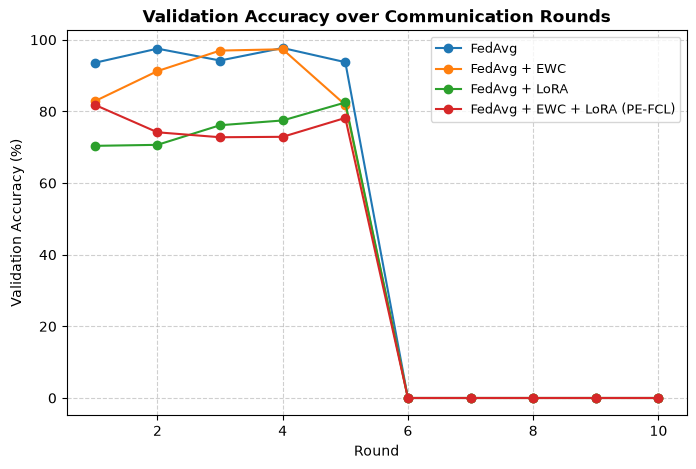

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, res in results.items():
    ax.plot(range(1, NUM_ROUNDS + 1), res['val_accs'], label=name, marker='o')

ax.set_title("Validation Accuracy over Communication Rounds", fontsize=12, fontweight='bold')
ax.set_xlabel("Round", fontsize=10)
ax.set_ylabel("Validation Accuracy (%)", fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=9)

save_plot("pefcl_experiment_comparison", fig=fig, caption="Comparison of federated continual learning strategies (FedAvg, EWC, LoRA, and the PE-FCL combination) over communication rounds.")
plt.show()

### Final Performance Comparison of Strategies

We present a side-by-side comparison of the final test accuracy and macro F1-score across all four evaluated federated continual learning strategies. This illustrates how incorporating Parameter-Efficient Fine-Tuning (LoRA) and Elastic Weight Consolidation (EWC) mitigates catastrophic forgetting in a decentralized, non-IID environment.

Saved figure to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/fcl_strategy_metrics_comparison_20260628_124520.png
Saved figure caption sidecar to: /Users/bernard/Developer/FORKS/mit-bih/notebooks/01-mit-bih-arrhythmia/assets/plots/fcl_strategy_metrics_comparison_20260628_124520.txt


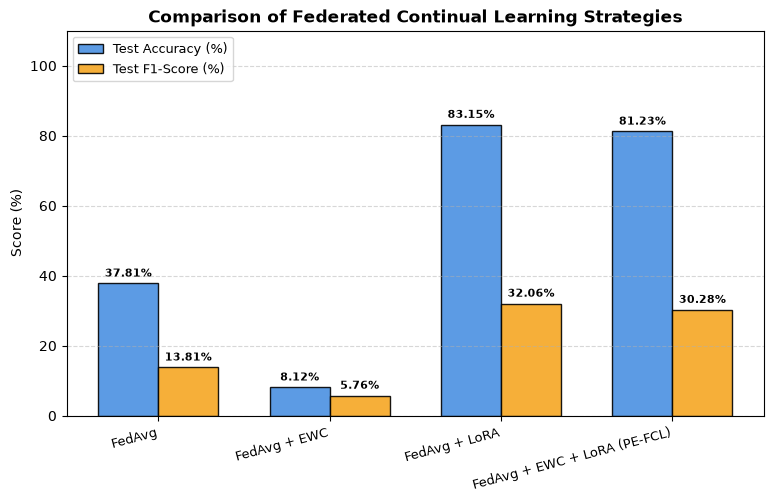

In [7]:
# Comparison of Final Test Metrics
categories = list(results.keys())
accuracies = [res['acc'] for res in results.values()]
f1_scores = [res['f1'] for res in results.values()]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, accuracies, width, label='Test Accuracy (%)', color='#4A90E2', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, f1_scores, width, label='Test F1-Score (%)', color='#F5A623', edgecolor='black', alpha=0.9)

ax.set_title("Comparison of Federated Continual Learning Strategies", fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("Score (%)", fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=9, loc='upper left')

# Add text labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}%",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

save_plot("fcl_strategy_metrics_comparison", fig=fig, caption="Bar chart comparing final test accuracy and macro F1-score of the four federated continual learning strategies on the global test set.")
plt.show()
